In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle, sys, os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator

In [3]:
import NNMFit
from NNMFit.utilities.readout_graphs import HistogramGraph
from NNMFit.core.analysis_config import AnalysisConfig

In [4]:
sys.path.append("/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks")
from plot_utils import *

Lets add some systematics!!

In [6]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/bin_migration_overlap_dortmund/plot_systematics"
os.system(f"mkdir -p {plotting_path}")

0

Lets create a benchmark of the analysis

- All: 92.66
- Conv: 9.90
- Prompt 4.31
- Astro 78.45
- NuE: 40.45
- NuMu: 14.85
- NuTau: 23.14

This seems to match with the benchmark HESE analysis from overlap/v3. In v3 is also had the combined HESE simulation sets.
Sum of casc,double,track
- Conv: 4.01+0.09+5.80 = 9.90
- Astro: 62.15+4.60+11.69 = 78.44

In [7]:
configs_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/configs/flavor_globalfit/"
config_hdl_systematics = AnalysisConfig.from_configs(
        main_config_file=f"{configs_dir}/main.cfg",
        analysis_config_file = f"{configs_dir}/analysis_configs/asimov/SAY/hese/hese_combined_HESEBestfit_SPL_3flavor.yaml",
        config_dir=configs_dir,
        override_dict=None,
        override_config_files=["override/systematics/NoSystematics_hese_combined.cfg"],
        override_components_files=["override/components/astro_SPL_3flavor.yaml"],
        override_parameters_files=None)
# build a histogram
hist_graph_hdl_systematics = HistogramGraph(config_hdl_systematics)
detector_configs = config_hdl_systematics.get_det_configs()

IC86_pass2_SnowStorm_FTP_HESE_Combined


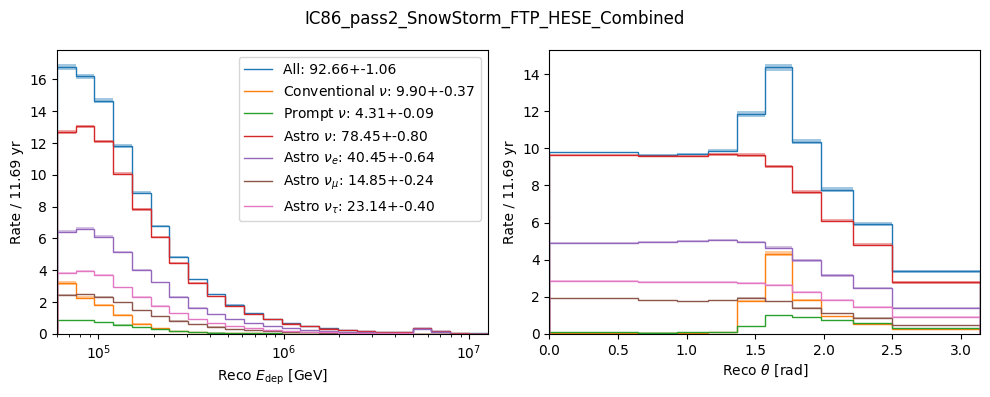

In [8]:
det_config = "IC86_pass2_SnowStorm_FTP_HESE_Combined"

input_variables = {
    r"All" : {"total_astro_norm" : 3*2.1233, "gamma" : 2.87, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 1, "conv_norm" : 1, "muongun_norm" : 0, "muon_norm" : 0},
    r"Conventional $\nu$" : {"total_astro_norm" : 0, "gamma" : 2.87, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 1, "muongun_norm" : 0, "muon_norm" : 0},
    r"Prompt $\nu$" : {"total_astro_norm" : 0, "gamma" : 2.87, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 1, "conv_norm" : 0, "muongun_norm" : 0, "muon_norm" : 0},
    r"Astro $\nu$" : {"total_astro_norm" : 3*2.1233, "gamma" : 2.87, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0, "muon_norm" : 0},
    r"Astro $\nu_e$" : {"total_astro_norm" : 2.1233, "gamma" : 2.87, "a" : 1.0, "b" : 1.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0,"muon_norm" : 0},
    r"Astro $\nu_\mu$" : {"total_astro_norm" : 2.1233, "gamma" : 2.87, "a" : 1.0, "b" : -1.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0, "muon_norm" : 0},
    r"Astro $\nu_\tau$" : {"total_astro_norm" : 2.1233, "gamma" : 2.87, "a" : 0.0, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0, "muon_norm": 0},
}


plot_histogram(
    hist_graph_hdl=hist_graph_hdl_systematics,
    det_config=det_config,
    input_variables=input_variables,
    ylog=False,
    savepath=f"{plotting_path}/Benchmark_{det_config}_ylog-False.png",
)

Now for separate systematics

In [9]:
configs_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/configs/flavor_globalfit/"
config_hdl_systematics = AnalysisConfig.from_configs(
        main_config_file=f"{configs_dir}/main.cfg",
        analysis_config_file = f"{configs_dir}/analysis_configs/asimov/SAY/hese/hese_combined_HESEBestfit_SPL_3flavor.yaml",
        config_dir=configs_dir,
        override_dict=None,
        override_config_files=["override/systematics/hese_combined/length_bdt1_bdt2.cfg",
                               "override/binning/hese/combined/cut_energy.cfg",
                               "override/binning/hese/combined/length_bdt1_bdt2.cfg",
                               "override/binning/hese/combined/cut_energy.cfg"],
        override_components_files=["override/components/astro_SPL_3flavor.yaml"],
        override_parameters_files=None)
# build a histogram
hist_graph_hdl_systematics = HistogramGraph(config_hdl_systematics)
detector_configs = config_hdl_systematics.get_det_configs()

IC86_pass2_SnowStorm_FTP_HESE_Combined


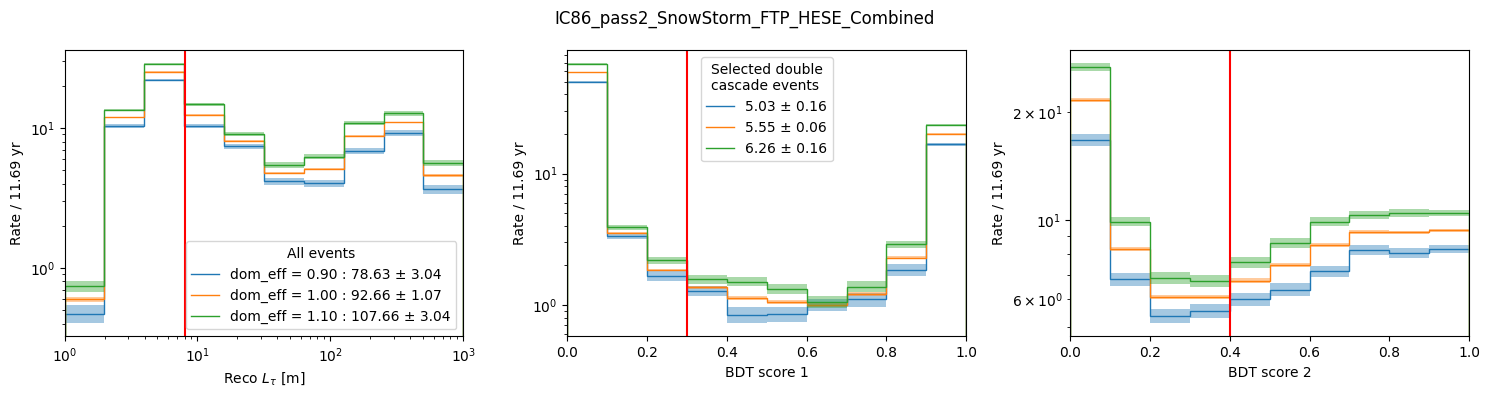

IC86_pass2_SnowStorm_FTP_HESE_Combined


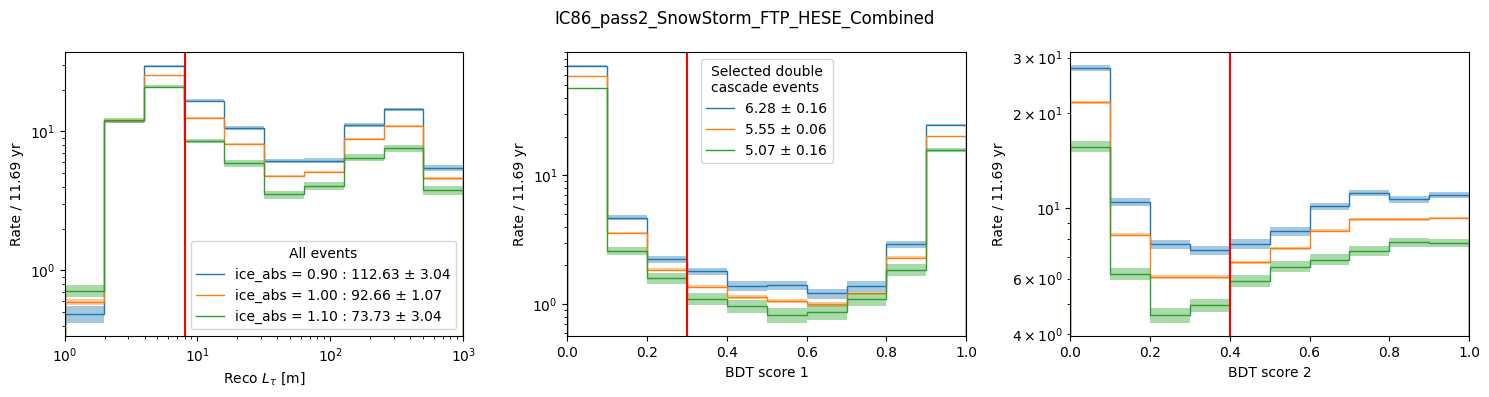

IC86_pass2_SnowStorm_FTP_HESE_Combined


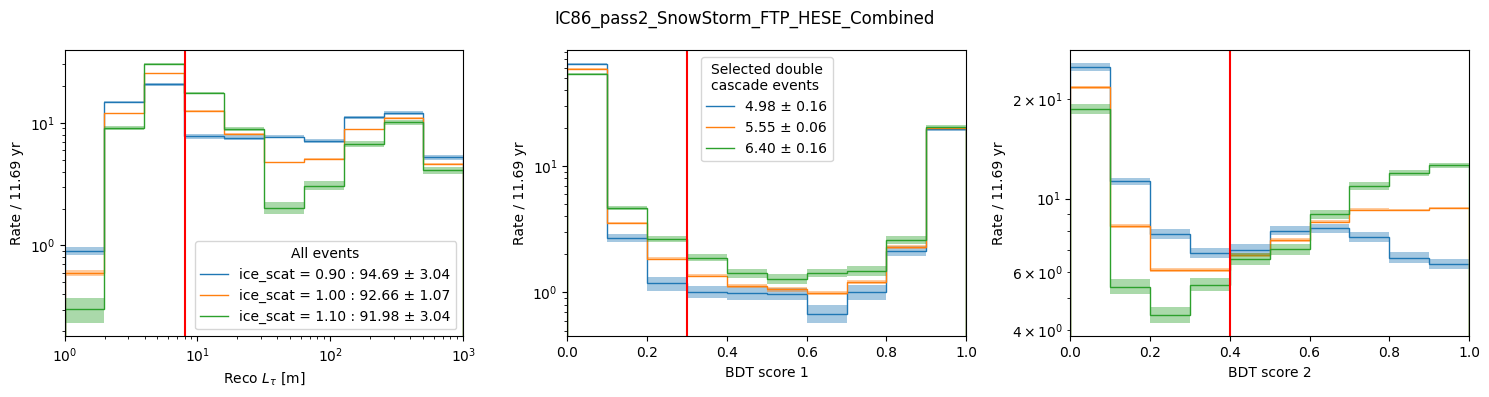

IC86_pass2_SnowStorm_FTP_HESE_Combined


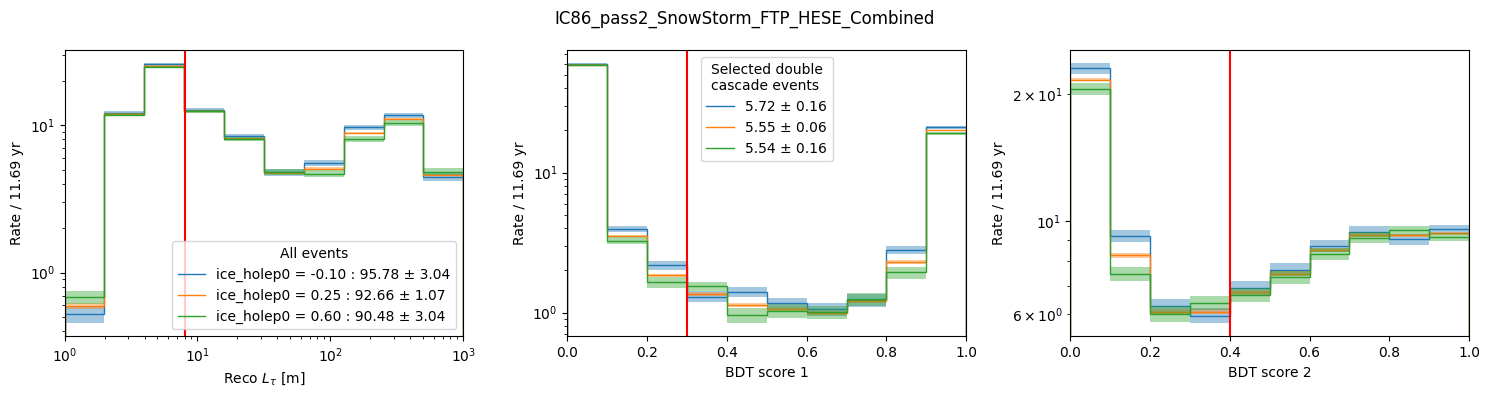

IC86_pass2_SnowStorm_FTP_HESE_Combined


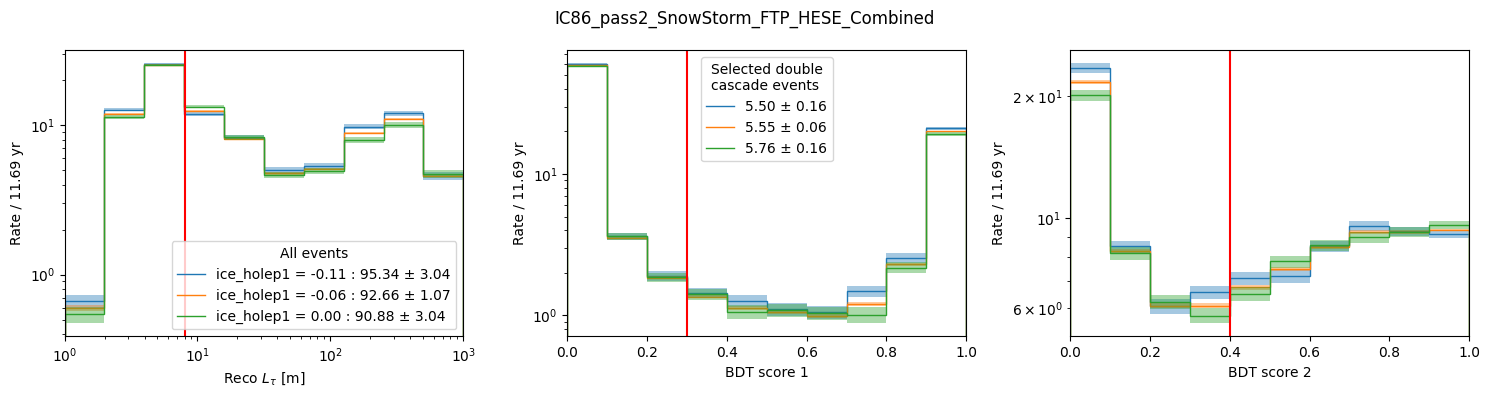

IC86_pass2_SnowStorm_FTP_HESE_Combined


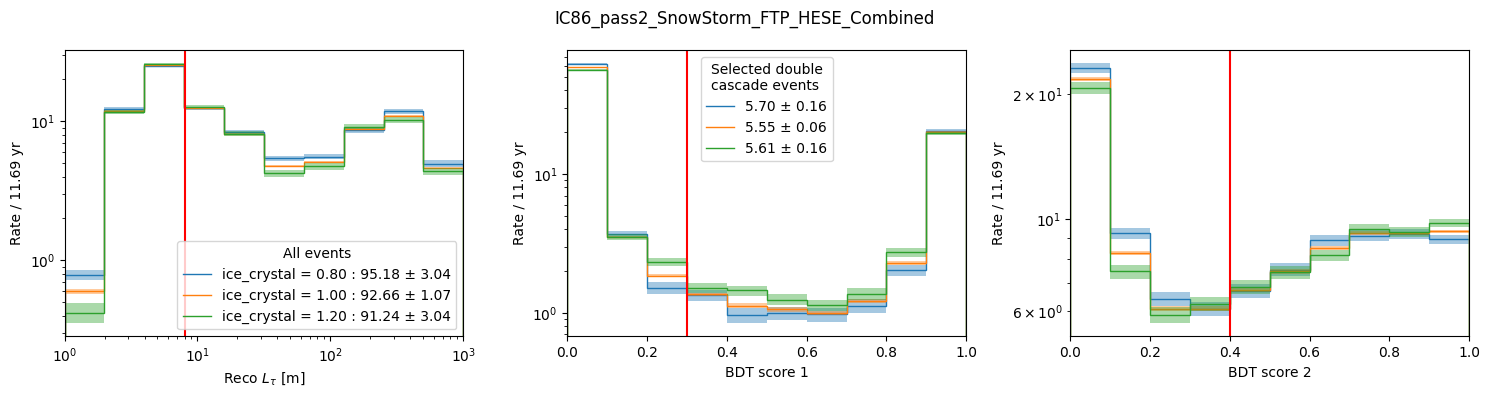

IC86_pass2_SnowStorm_FTP_HESE_Combined


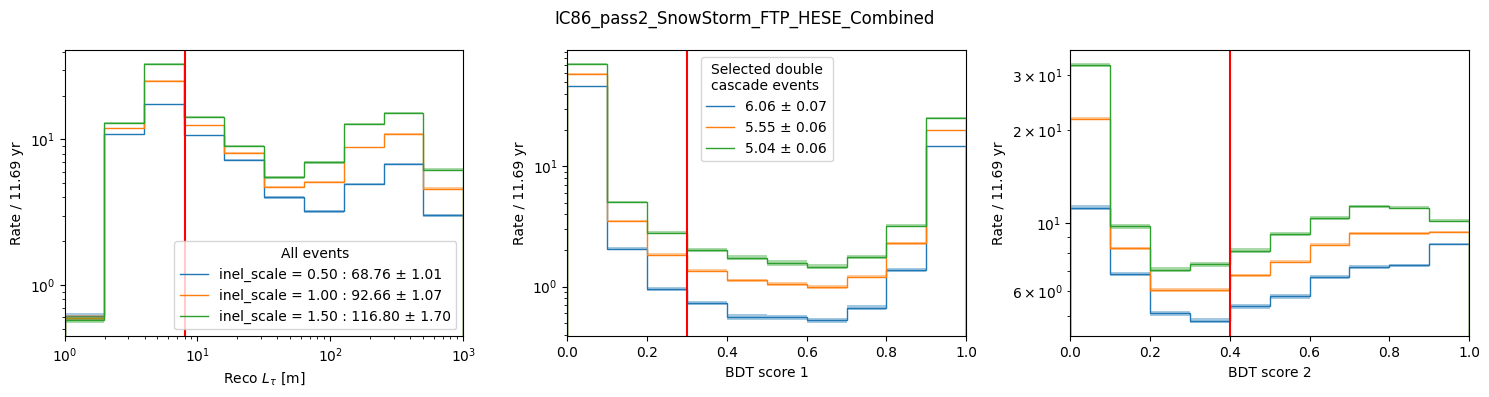

In [29]:
import numpy as np
from utils import *

# Parameter names
param_names = ["dom_eff", "ice_abs", "ice_scat", "ice_holep0", "ice_holep1", "ice_crystal", "inel_scale"]

# Default values
default_values = [1.0, 1.0, 1.0, 0.24901831812365854, -0.05678798504997925, 1.0, 1.0]

# Ranges for each parameter
param_ranges = [
    (0.9, 1.1),           # dom_eff
    (0.9, 1.1),           # ice_abs
    (0.9, 1.1),           # ice_scat
    (-0.1, 0.5980366362473171),   # ice_holep0
    (-0.1135759700999585, 0.0),   # ice_holep1
    (0.8, 1.2),            # ice_crystal
    (0.5, 1.5),            # inel_scale
]

cuts = {
    # "reco_length": (1e1, 1e3),
    "reco_length": (8, 1e3),
    # "bdt_scores1": (0.3333333, 1.1),
    "bdt_scores1": (0.3, 1.1),
    # "bdt_scores2": (0.3666667, 1.1),
    "bdt_scores2": (0.4, 1.1),
}

# cuts = {}

base_params = {
    "conv_norm" : 1.0,
    "prompt_norm" : 1.0,
    "total_astro_norm": 6.3699,
    "a": 0.4444444444,
    "b": 0.0,
}

n_points = 3  # how many points to sample in each range

for i, param in enumerate(param_names):
    # generate values in the range (linear spacing)
    values = np.linspace(param_ranges[i][0], param_ranges[i][1], n_points)

    # build input_variables dict for this parameter
    input_variables = {}
    for val in values:
        params = dict(zip(param_names, default_values))  # start from default
        params.update(base_params)    
        params[param] = val                             # override current parameter
        input_variables[f"{param} = {val:.2f}"] = params

    # loop over detector configs and plot
    for det_config in detector_configs:
        # for ylog in [True,False]:
        for ylog in [True]:
            plot_histogram_annotate_selection(
                hist_graph_hdl=hist_graph_hdl_systematics,
                det_config=det_config,
                cuts=cuts,
                input_variables=input_variables,
                ylog=ylog,
                # savepath=f"{plotting_path}/Example_nocuts_{det_config}_{param}_ylog-{ylog}.png"
                savepath=f"{plotting_path}/{det_config}_{param}_ylog-{ylog}.png"
            )
    #         break
    #     break
    # break


IC86_pass2_SnowStorm_FTP_HESE_Combined


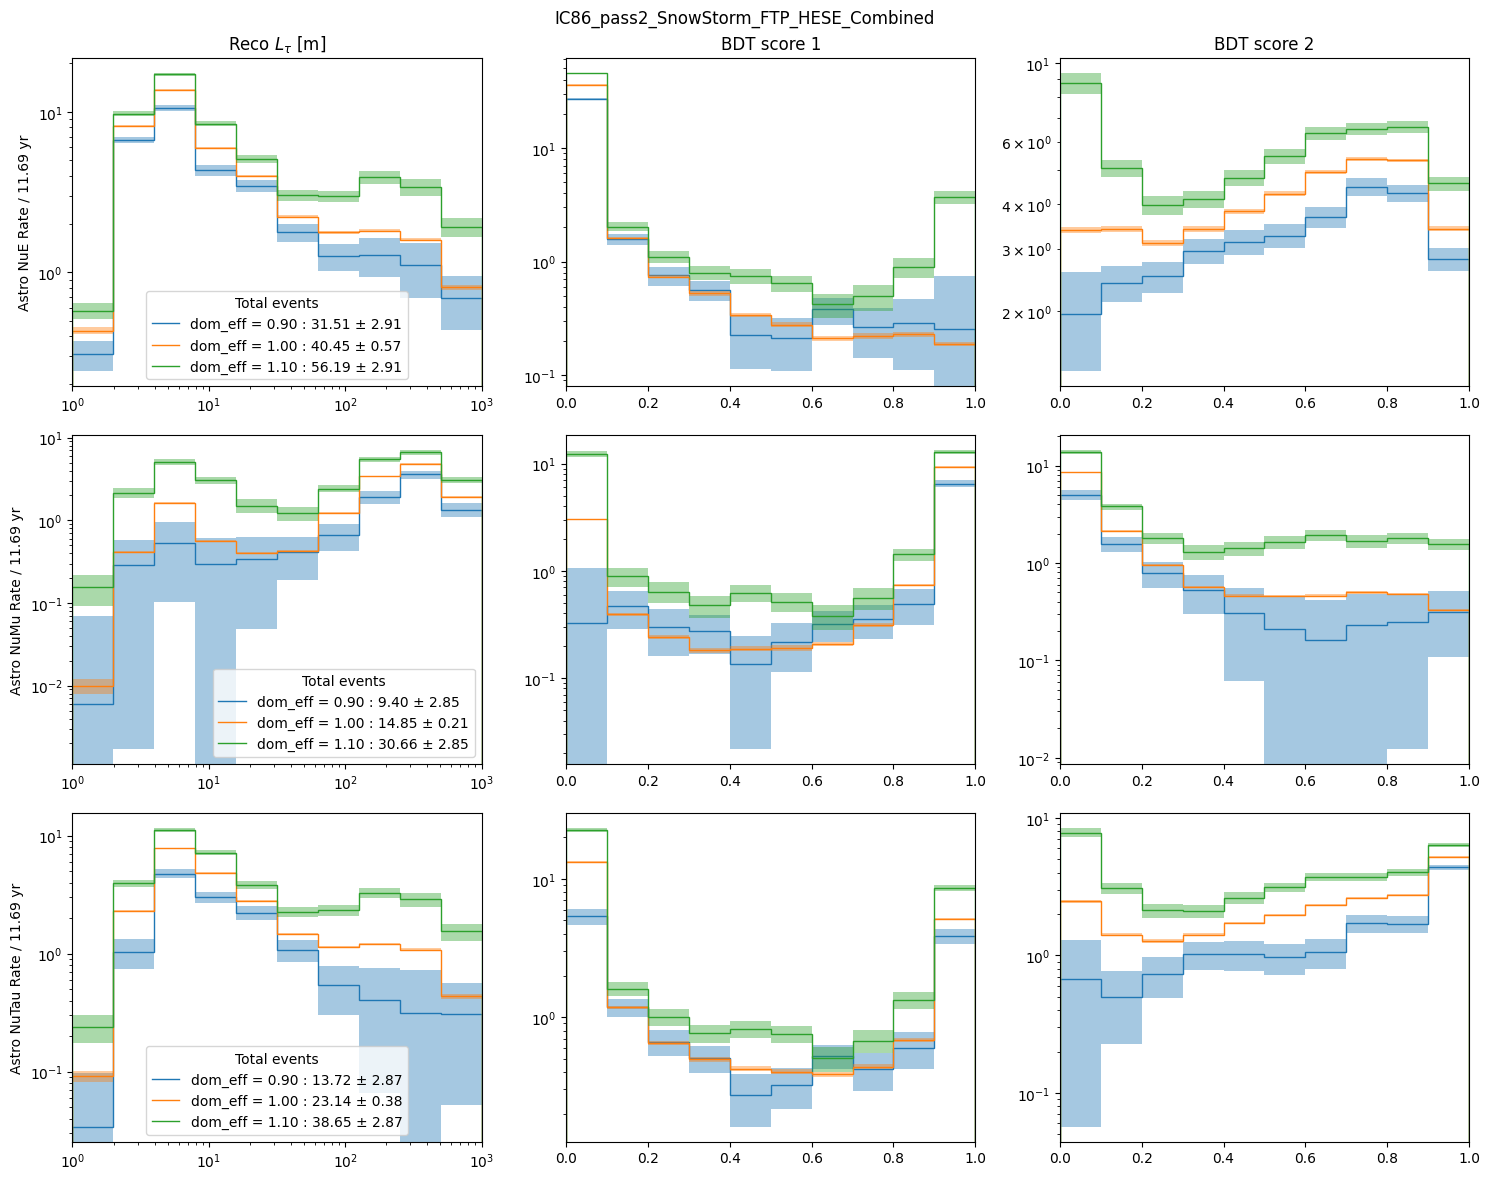

IC86_pass2_SnowStorm_FTP_HESE_Combined


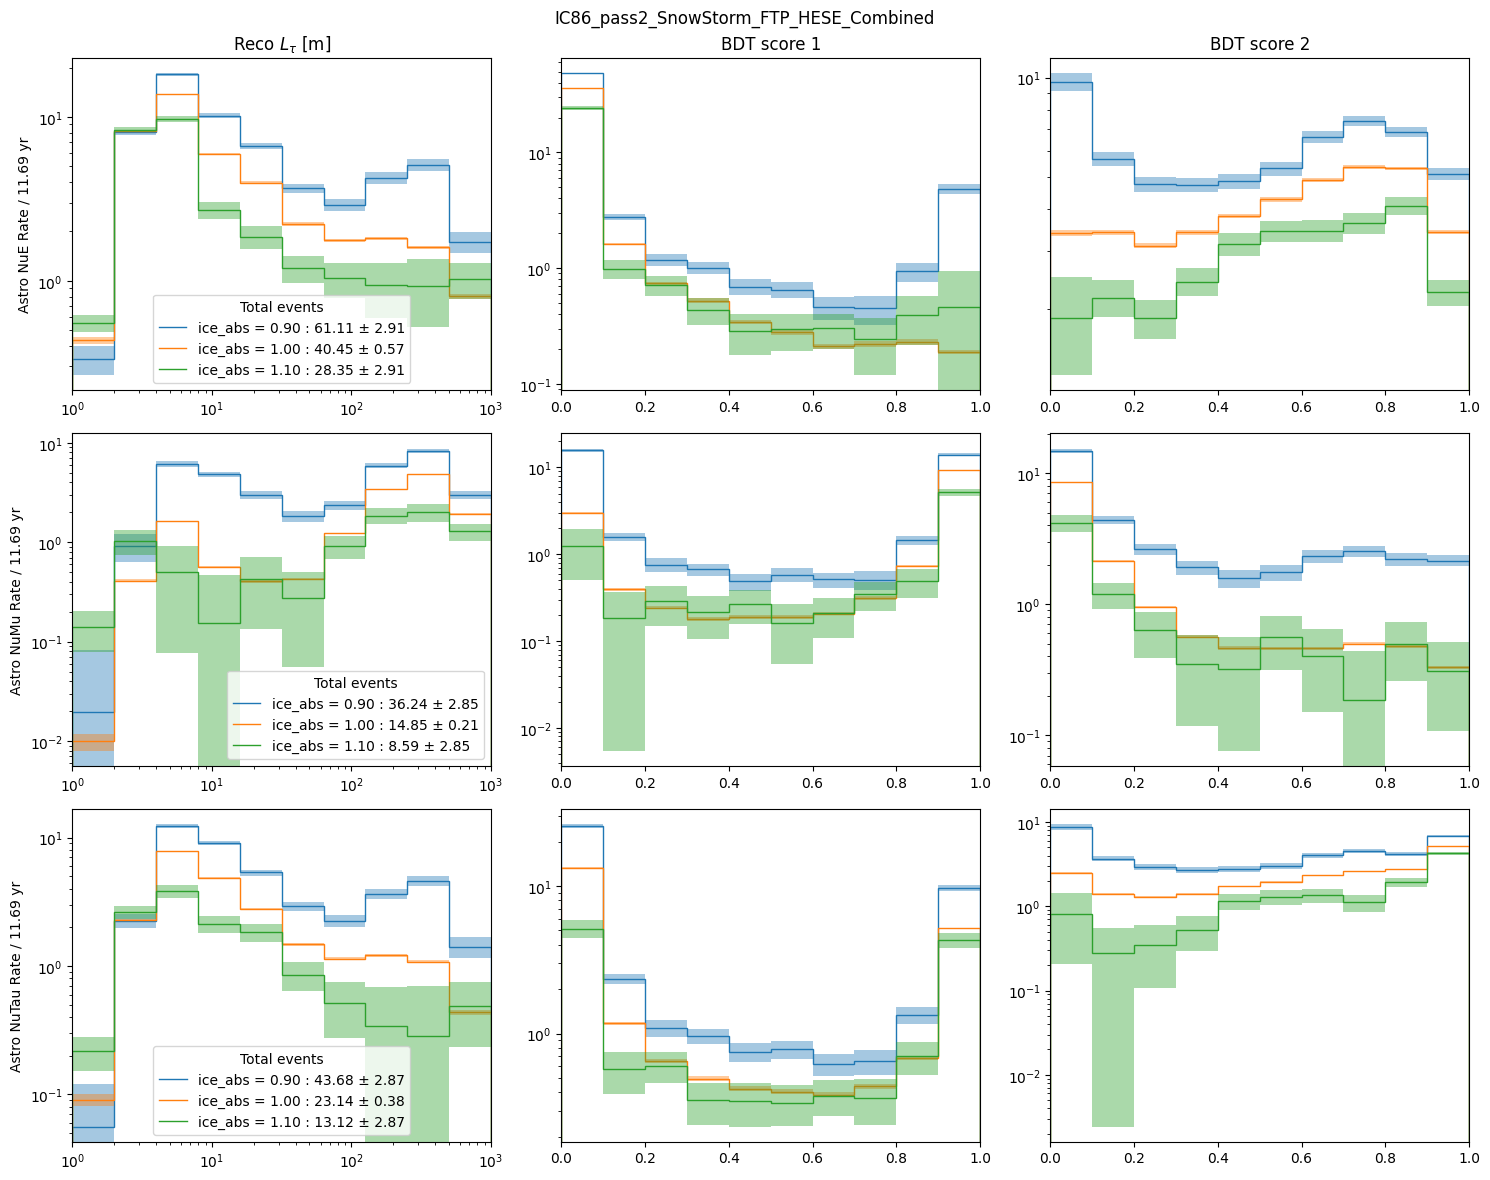

IC86_pass2_SnowStorm_FTP_HESE_Combined


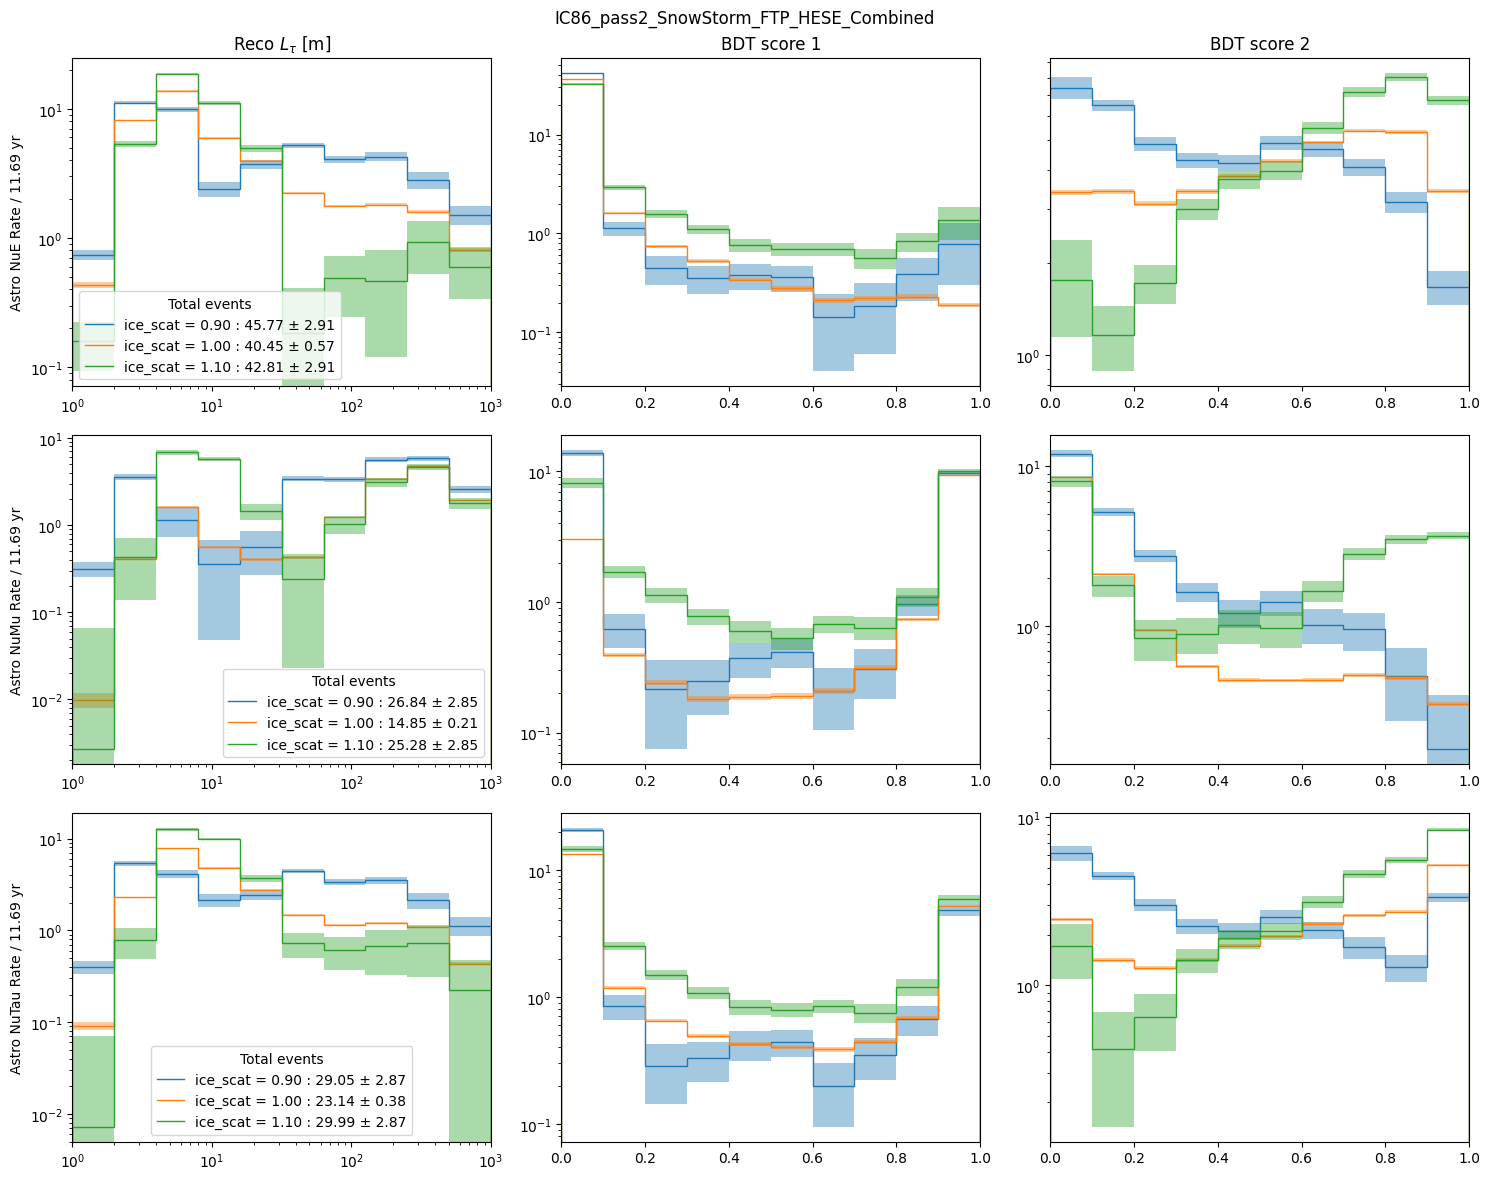

IC86_pass2_SnowStorm_FTP_HESE_Combined


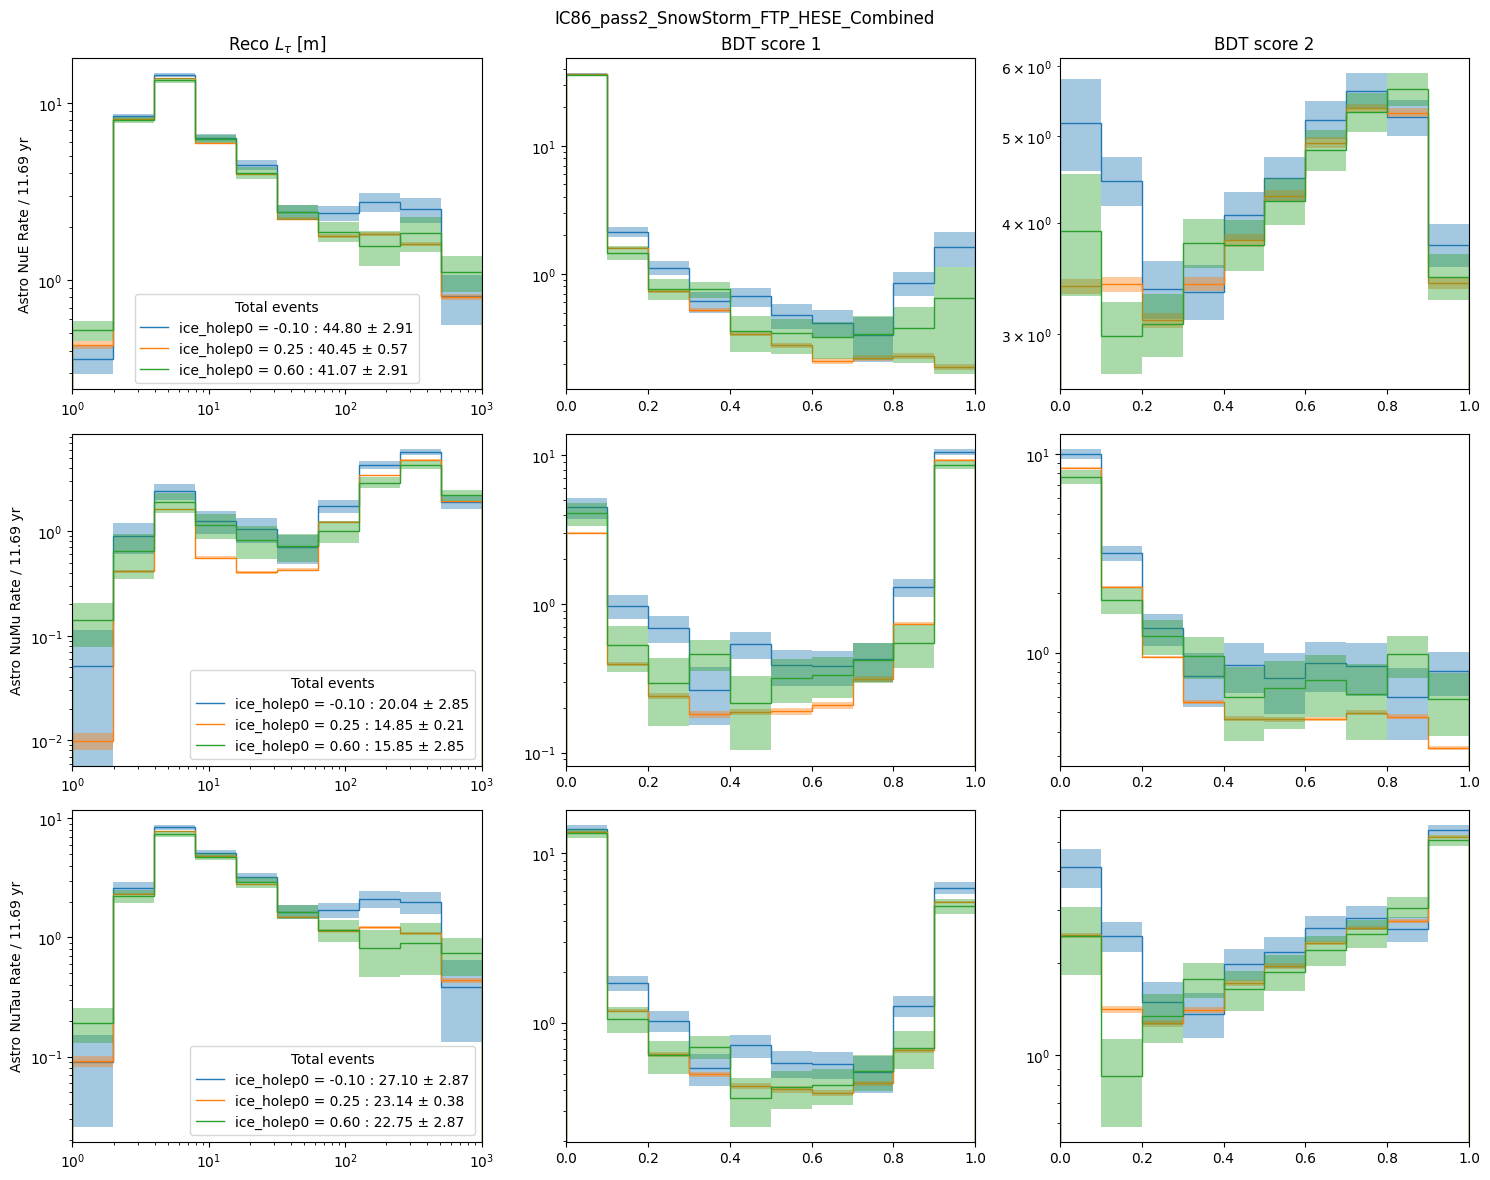

IC86_pass2_SnowStorm_FTP_HESE_Combined


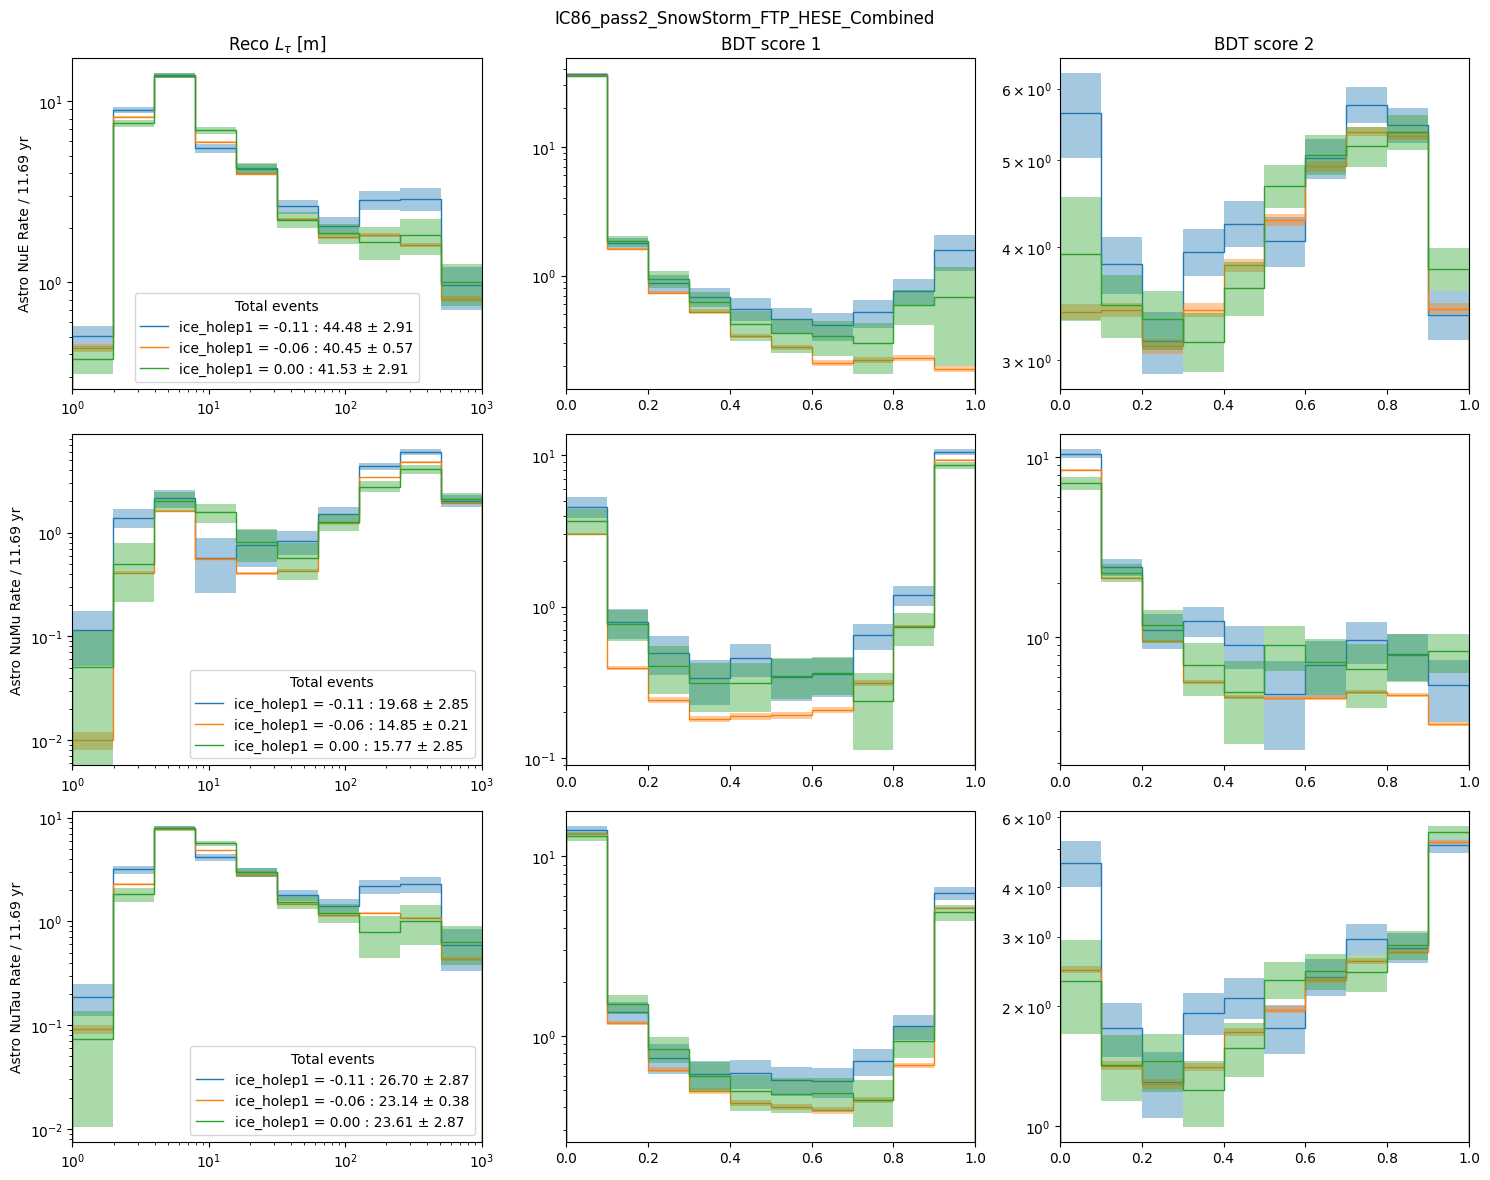

IC86_pass2_SnowStorm_FTP_HESE_Combined


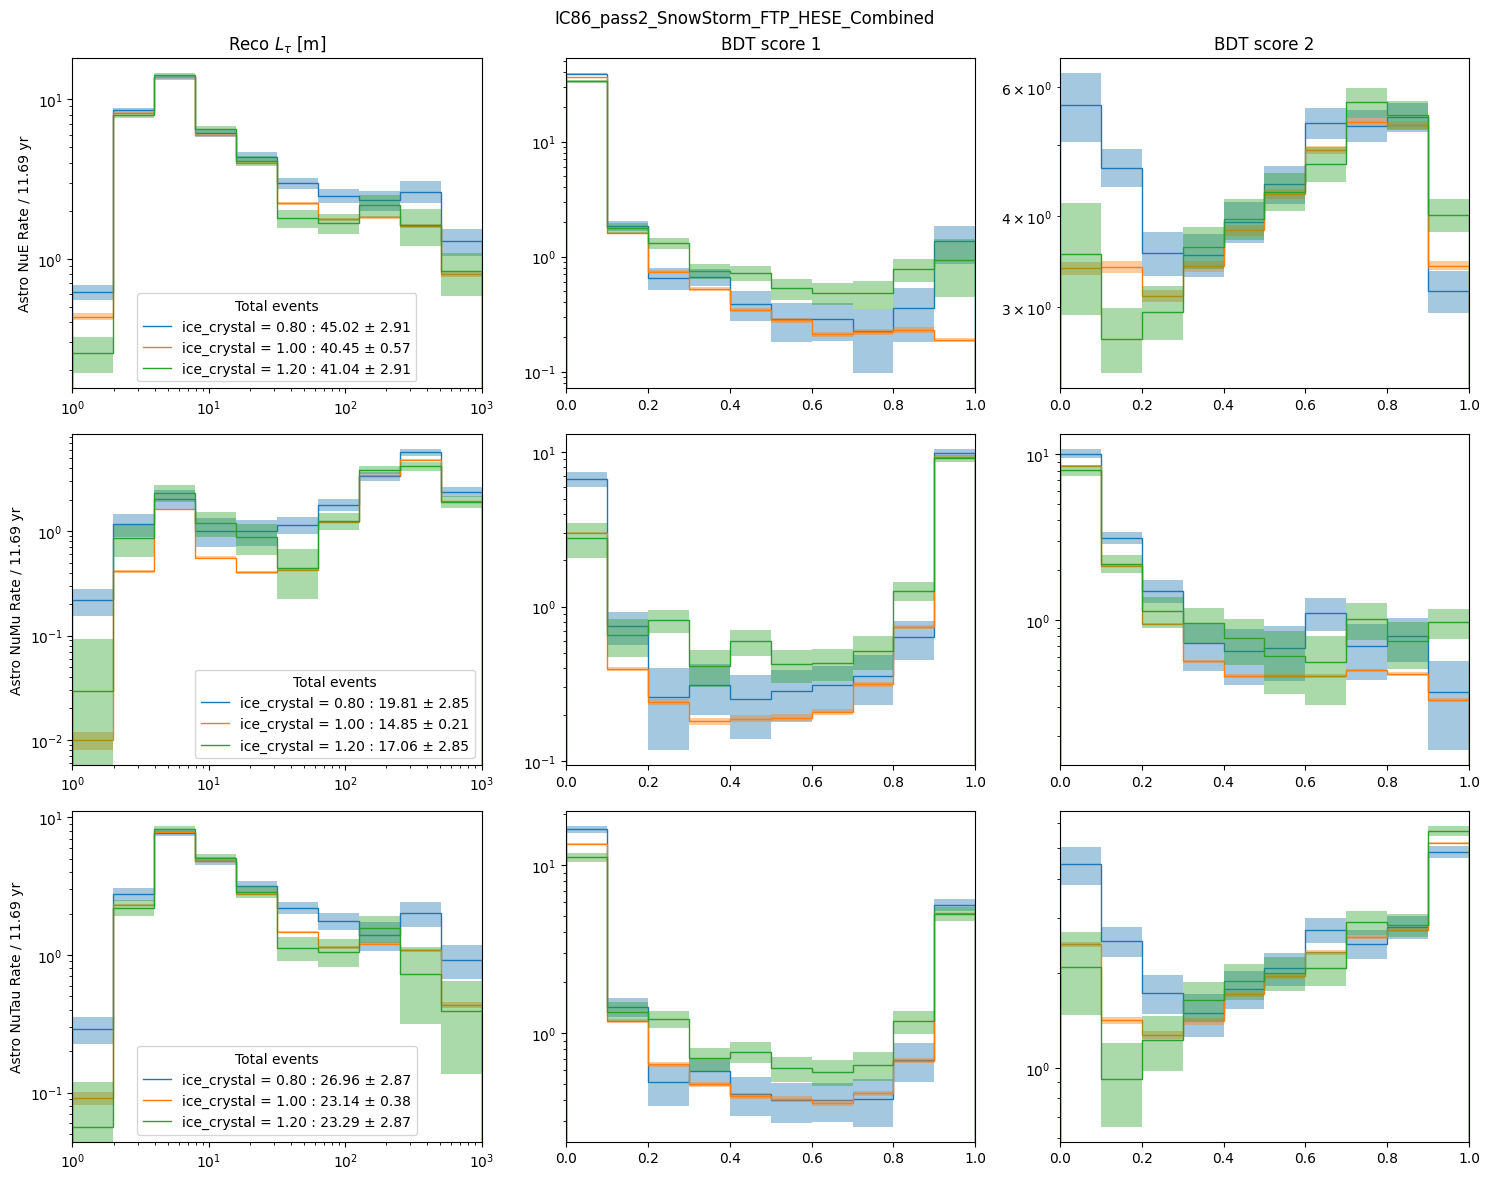

IC86_pass2_SnowStorm_FTP_HESE_Combined


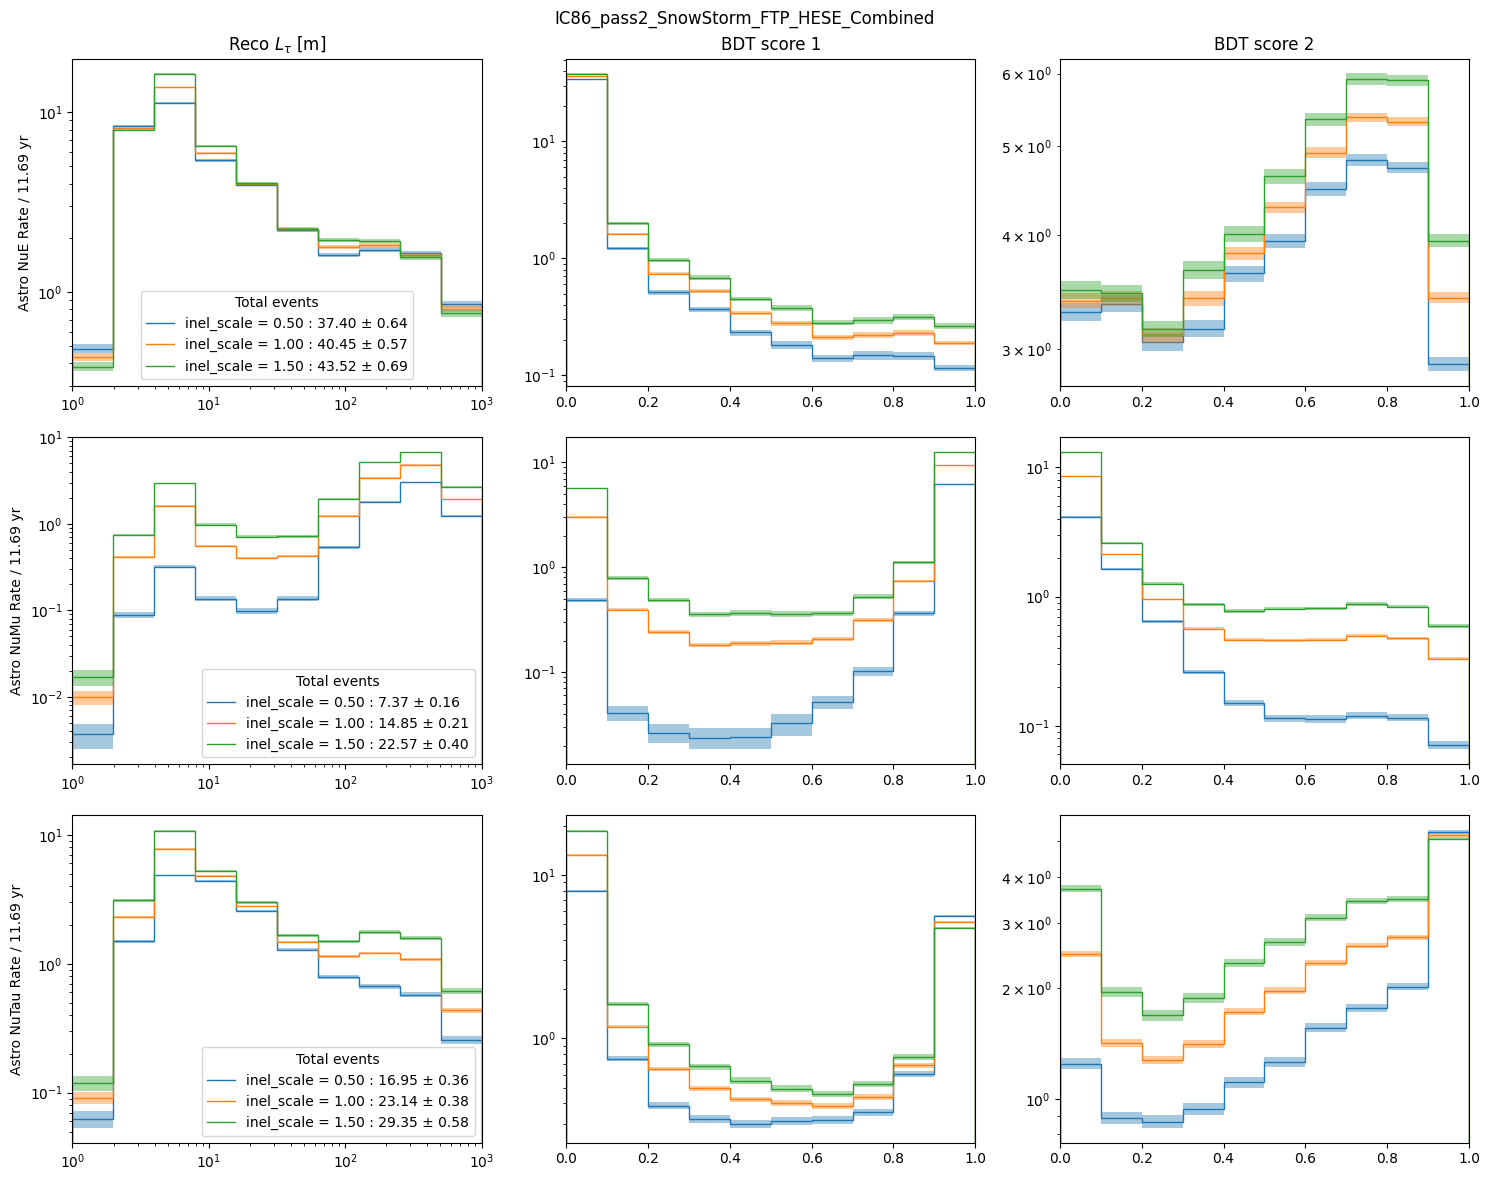

In [20]:
import numpy as np
from utils import *

# Parameter names
param_names = ["dom_eff", "ice_abs", "ice_scat", "ice_holep0", "ice_holep1", "ice_crystal", "inel_scale"]

# Default values
default_values = [1.0, 1.0, 1.0, 0.24901831812365854, -0.05678798504997925, 1.0, 1.0]

# Ranges for each parameter
param_ranges = [
    (0.9, 1.1),           # dom_eff
    (0.9, 1.1),           # ice_abs
    (0.9, 1.1),           # ice_scat
    (-0.1, 0.5980366362473171),   # ice_holep0
    (-0.1135759700999585, 0.0),   # ice_holep1
    (0.8, 1.2),            # ice_crystal
    (0.5, 1.5),            # inel_scale
]

cuts = {
    "reco_length": (1e1, 1e3),
    "bdt_scores1": (0.3333333, 1.1),
    "bdt_scores2": (0.3666667, 1.1),
}

base_params = {
    "conv_norm" : 1.0,
    "prompt_norm" : 1.0,
    "total_astro_norm": 6.3699,
    "a": 0.4444444444,
    "b": 0.0,
}

n_points = 3  # how many points to sample in each range

for i, param in enumerate(param_names):
    # generate values in the range (linear spacing)
    values = np.linspace(param_ranges[i][0], param_ranges[i][1], n_points)

    # build input_variables dict for this parameter
    input_variables = {}
    for val in values:
        params = dict(zip(param_names, default_values))  # start from default
        params.update(base_params)    
        params[param] = val                             # override current parameter
        input_variables[f"{param} = {val:.2f}"] = params

    # loop over detector configs and plot
    for det_config in detector_configs:
        for ylog in [True]:
            plot_histogram_annotate_selection_flavor(
                hist_graph_hdl=hist_graph_hdl_systematics,
                det_config=det_config,
                cuts=cuts,
                input_variables=input_variables,
                ylog=ylog,
                savepath=f"{plotting_path}/Flavor_{det_config}_{param}_ylog-{ylog}.png"
            )
    #         break
    #     break
    # break
